# 03 - M7 (7 clases)

Clasificación multiclase con los 12 modelos repetida `N_RUNS` veces (10 por defecto) con splits distintos (tuning con GridSearchCV en la primera corrida), test de Wilcoxon, análisis SHAP y clasificación con las 10 features más importantes.

In [1]:
from functools import partial

import pandas as pd

from csp_perovskites import config, io, plotting, preprocessing as pp
from csp_perovskites import datasets as ds, evaluation as ev, models, shap_analysis as sa

## Parámetros

In [ ]:
N_RUNS = config.N_RUNS
CV = config.CV_FOLDS
SCALER = "minmax"          # "minmax" (paper), "standard" o None
MODELS = None              # None = los 12 modelos; o una lista de nombres
SHAP_MAX_SAMPLES = None    # submuestreo del test para acelerar SHAP
N_JOBS = config.N_JOBS     # -1 = todos los núcleos; bajarlo si falta RAM; 1 = secuencial
DROP_POLYMORPHS_FROM_TEST = False  # True = evaluar solo en compuestos con una sola etiqueta

split_fn = partial(ds.make_m7_split, drop_polymorphs_from_test=DROP_POLYMORPHS_FROM_TEST)
df = pp.clean_master(io.load_master())
df_decor, _ = pp.decorrelate(df)

## Clasificación con todas las features

In [3]:
full = ev.run_repeated(df_decor, split_fn, models.get_classifiers(MODELS),
                       n_runs=N_RUNS, cv=CV, scaler=SCALER, n_jobs=N_JOBS)
summary = ev.summarize(full.runs)
io.save_table(full.runs, "M7_runs.csv")
io.save_table(summary, "M7_summary.csv", index=True)
io.save_table(pd.DataFrame({m: [p] for m, p in full.best_params.items()}).T.rename(columns={0: "best_params"}),
              "M7_best_params.csv", index=True)
ev.summarize(full.runs, as_text=True)

Run 1/10 (seed=42): tuning hyperparameters
  Logistic Regression      acc=0.3660  f1=0.2444  auc=0.7607  (3.6s)
  Naive Bayes              acc=0.3271  f1=0.1955  auc=0.7148  (0.0s)
  K-Nearest Neighbors      acc=0.4782  f1=0.2029  auc=0.5874  (1.6s)
  Decision Tree            acc=0.5109  f1=0.2294  auc=0.5688  (2.9s)
  Random Forest            acc=0.5771  f1=0.2388  auc=0.7540  (66.5s)
  Extra Trees              acc=0.5763  f1=0.2386  auc=0.5965  (9.3s)
  AdaBoost                 acc=0.4330  f1=0.2714  auc=0.7862  (38.4s)
  Gradient Boosting        acc=0.5942  f1=0.2888  auc=0.8175  (310.6s)
  XGBoost                  acc=0.5942  f1=0.3141  auc=0.8301  (7.0s)
  LightGBM                 acc=0.5896  f1=0.2551  auc=0.8089  (9.6s)
  Support Vector Machine   acc=0.5304  f1=0.2951  auc=0.7635  (97.2s)
  Neural Network           acc=0.5530  f1=0.2616  auc=0.8169  (44.5s)
Runs 2-10: 108 fits in parallel (n_jobs=-1)
  run  3  Naive Bayes              acc=0.3590  f1=0.2202  auc=0.7274  (0.0s)
  

,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,fit_time,predict_time
model,,,,,,,
Gradient Boosting,0.5995 ± 0.0109,0.3095 ± 0.0196,0.2984 ± 0.0166,0.3407 ± 0.0270,0.8159 ± 0.0116,188.8588 ± 42.7776,0.0533 ± 0.0006
LightGBM,0.5963 ± 0.0135,0.2571 ± 0.0158,0.2583 ± 0.0153,0.2579 ± 0.0167,0.8142 ± 0.0097,6.0795 ± 1.2800,0.2570 ± 0.0191
XGBoost,0.5945 ± 0.0155,0.3334 ± 0.0219,0.3146 ± 0.0174,0.3993 ± 0.0346,0.8268 ± 0.0124,4.6712 ± 0.9113,0.0423 ± 0.0104
Random Forest,0.5915 ± 0.0150,0.2598 ± 0.0171,0.2591 ± 0.0168,0.2643 ± 0.0184,0.7644 ± 0.0162,29.9442 ± 12.8608,0.2461 ± 0.0067
Extra Trees,0.5909 ± 0.0128,0.2545 ± 0.0149,0.2552 ± 0.0145,0.2579 ± 0.0173,0.6049 ± 0.0115,6.9070 ± 0.8564,0.2083 ± 0.0130
Neural Network,0.5621 ± 0.0235,0.2849 ± 0.0167,0.2764 ± 0.0140,0.3214 ± 0.0200,0.8195 ± 0.0075,29.5564 ± 6.5985,0.0041 ± 0.0003
Support Vector Machine,0.5379 ± 0.0161,0.3150 ± 0.0147,0.3006 ± 0.0115,0.4162 ± 0.0249,0.7689 ± 0.0125,49.0429 ± 17.0146,1.8422 ± 0.3396
Decision Tree,0.5181 ± 0.0106,0.2243 ± 0.0151,0.2213 ± 0.0129,0.2334 ± 0.0183,0.5642 ± 0.0098,0.9272 ± 0.7012,0.0040 ± 0.0008
K-Nearest Neighbors,0.4984 ± 0.0161,0.2219 ± 0.0149,0.2221 ± 0.0125,0.2351 ± 0.0199,0.5888 ± 0.0114,0.1776 ± 0.5002,0.3148 ± 0.1071


## Test de Wilcoxon entre los mejores modelos

In [4]:
top = [m for m in config.TOP_MODELS if m in full.best_params]
ev.wilcoxon_pairwise(full.runs, top, metric="accuracy")

,model_a,model_b,W,p_value
0,Random Forest,Extra Trees,26.0,0.898438
1,Random Forest,LightGBM,8.0,0.048828
2,Extra Trees,LightGBM,13.5,0.169922


## SHAP (Random Forest, Extra Trees, LightGBM)

Random Forest    acc=0.5826  (221.7s)
Extra Trees      acc=0.5833  (557.0s)
LightGBM         acc=0.5935  (6.9s)
Top-10 SHAP:   ['END_B', 'AM_A', 'END_A', 'MPR_A', 'ARR_B', 'VR_B', 'IE_B', 'BP_A', 'D_A', 't']
Top-10 paper:  ['END_B', 'MPR_A', 'AM_A', 'END_A', 'IE_B', 'BP_A', 'ARR_B', 'VR_B', 'ARR_A', 't']


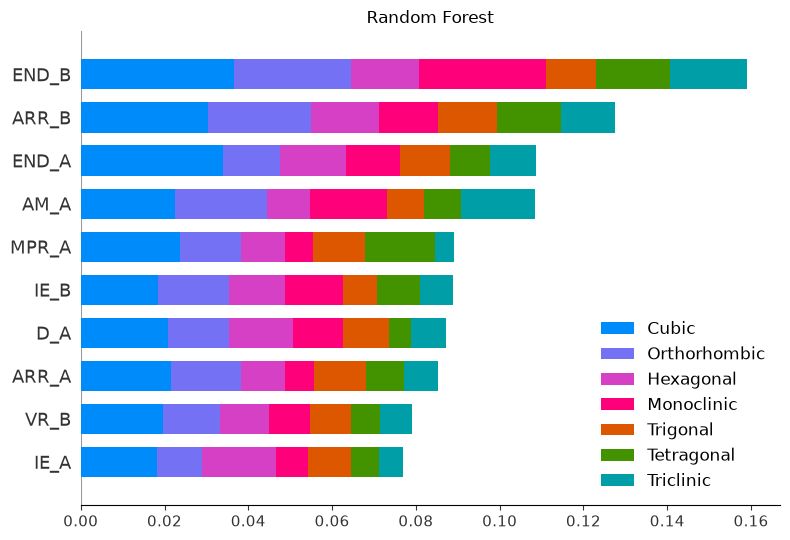

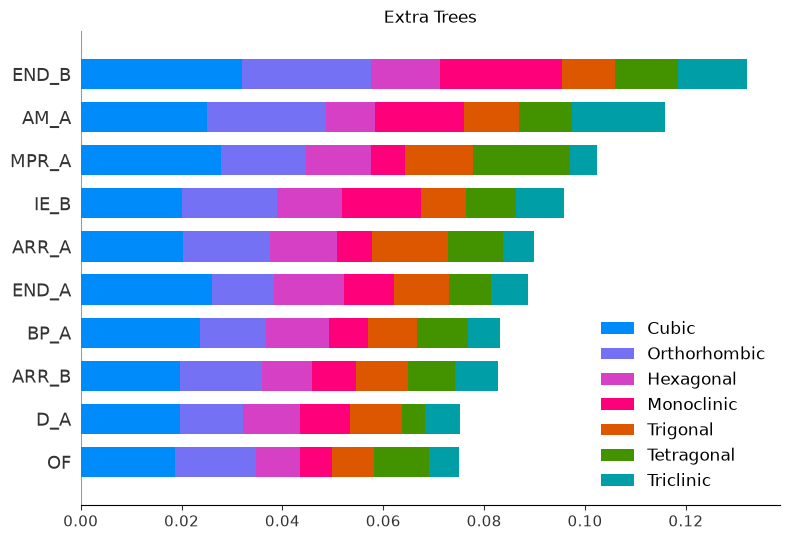

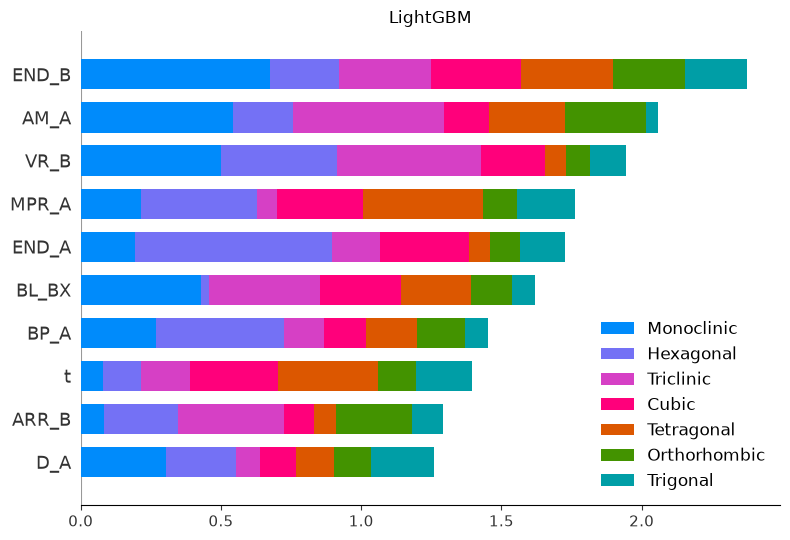

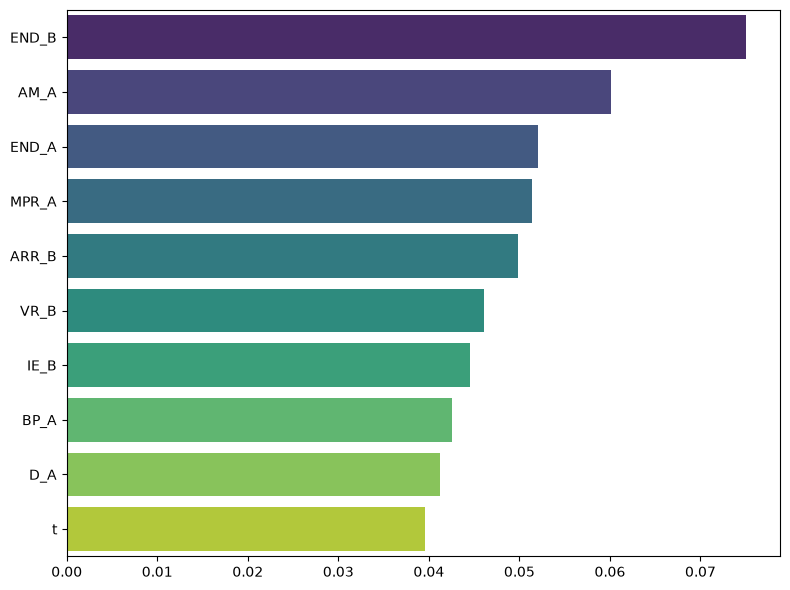

In [5]:
shap_results = sa.explain_models(split_fn(df_decor, seed=config.RANDOM_STATE),
                                max_samples=SHAP_MAX_SAMPLES, n_jobs=N_JOBS)
for model_name, result in shap_results.items():
    fig = sa.plot_shap_summary(result, top_k=10, title=model_name)
    io.save_fig(fig, f"M7_{model_name.replace(' ', '')}_shap_top10.png", directory=config.SHAP_DIR)

combined = sa.combine_importances(shap_results, normalize=True)
io.save_csv(combined, config.SHAP_DIR / "Combined_SHAP_importance_M7.csv")
fig = plotting.top_features_bar(combined, k=10)
io.save_fig(fig, "top10_features_M7.png")

shap_top10 = sa.top_k_features(combined, k=10)
print("Top-10 SHAP:  ", shap_top10)
print("Top-10 paper: ", config.TOP10_M7)

## Clasificación con features reducidas (M7*)

Por defecto se usa la lista del paper (`config.TOP10_M7`); cambia a `shap_top10` para usar la calculada arriba.

In [6]:
REDUCED_FEATURES = config.TOP10_M7

reduced = ev.run_repeated(df_decor, partial(split_fn, features=REDUCED_FEATURES),
                          models.get_classifiers(config.TOP_MODELS), n_runs=N_RUNS, cv=CV, scaler=SCALER,
                          n_jobs=N_JOBS)
io.save_table(reduced.runs, "M7_reduced_runs.csv")

cols = ["accuracy_mean", "accuracy_std", "fit_time_mean", "predict_time_mean"]
comparison = pd.concat({"M7": summary.loc[config.TOP_MODELS, cols],
                        "M7*": ev.summarize(reduced.runs).loc[config.TOP_MODELS, cols]}, axis=1)
io.save_table(comparison, "M7_vs_reduced.csv", index=True)
comparison

Run 1/10 (seed=42): tuning hyperparameters
  Random Forest            acc=0.5639  f1=0.2470  auc=0.7314  (57.1s)
  Extra Trees              acc=0.5623  f1=0.2421  auc=0.6059  (7.9s)
  LightGBM                 acc=0.5927  f1=0.2491  auc=0.8103  (5.4s)
Runs 2-10: 27 fits in parallel (n_jobs=-1)
  run  2  LightGBM                 acc=0.5903  f1=0.2640  auc=0.8127  (2.0s)
  run  4  LightGBM                 acc=0.5974  f1=0.2821  auc=0.8145  (2.0s)
  run  6  LightGBM                 acc=0.5833  f1=0.2431  auc=0.8019  (2.0s)
  run  7  LightGBM                 acc=0.5732  f1=0.2466  auc=0.7973  (2.0s)
  run 10  LightGBM                 acc=0.5693  f1=0.2389  auc=0.8087  (2.1s)
  run  3  LightGBM                 acc=0.6075  f1=0.2654  auc=0.8236  (2.1s)
  run  9  LightGBM                 acc=0.5950  f1=0.2690  auc=0.8107  (2.1s)
  run  5  LightGBM                 acc=0.5974  f1=0.2631  auc=0.7976  (2.0s)
  run  8  LightGBM                 acc=0.6020  f1=0.2647  auc=0.8025  (2.0s)
  run 10  Ext

M7                                               \
              accuracy_mean accuracy_std fit_time_mean predict_time_mean   
model                                                                      
Random Forest      0.591511     0.014950     29.944195          0.246097   
Extra Trees        0.590888     0.012761      6.906999          0.208300   
LightGBM           0.596262     0.013450      6.079548          0.256967   

                        M7*                                               
              accuracy_mean accuracy_std fit_time_mean predict_time_mean  
model                                                                     
Random Forest      0.567835     0.014269     33.430425          0.460531  
Extra Trees        0.562617     0.011869      4.158968          0.194355  
LightGBM           0.590810     0.012194      2.358641          0.202305

## Comparación M4 vs M7 (requiere haber corrido `02_M4.ipynb`)

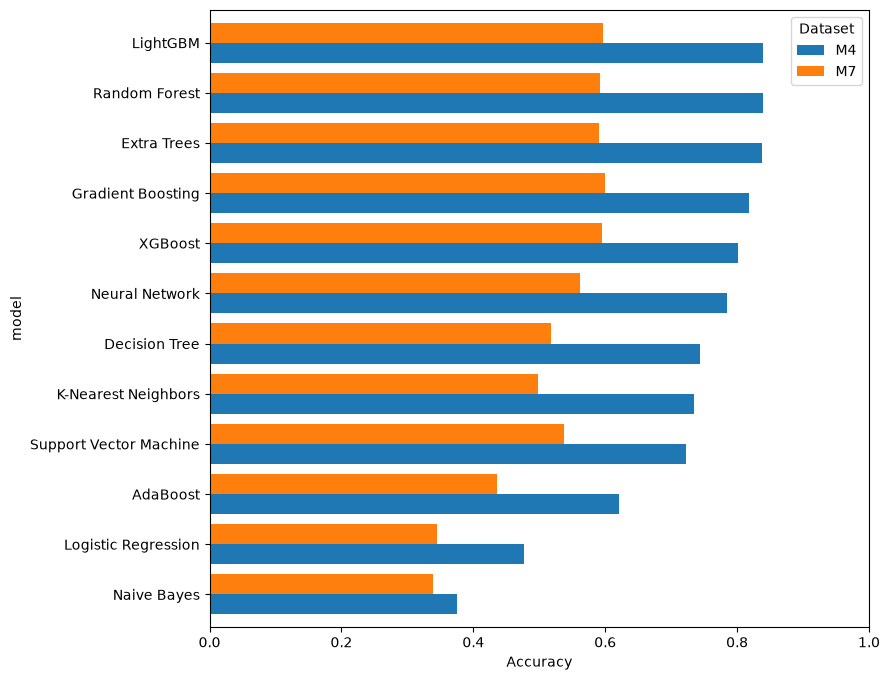

In [7]:
m4_path = config.TABLES_DIR / "M4_summary.csv"
if m4_path.exists():
    m4_summary = pd.read_csv(m4_path, index_col=0)
    fig = plotting.metric_bars({"M4": m4_summary, "M7": summary}, metric="accuracy_mean")
    io.save_fig(fig, "classifier_accuracies_M4_M7.png")